In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sweetviz as sv

from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, cross_val_score
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score, recall_score,
    precision_score, classification_report
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.feature_selection import SelectFromModel

target = `accepted_offer`

In [60]:
train = pd.read_csv('midterm_train.csv')
train.head(10)

,id,customer_age,occupation_type,relationship_status,education_background,has_credit_issue,mortgage_status,personal_loan_status,last_contact_month,day_of_week,...,prior_contact_count,prior_outcome_status,economic_activity_change,consumer_price_index,consumer_confidence_index,reference_interest_rate,employment_level_index,accepted_offer,is_repeat_customer,recent_contact_flag
0,12556,28,services,married,high.school,no,yes,no,jul,tue,...,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,0,0,0
1,35451,27,admin.,married,university.degree,no,yes,yes,jul,fri,...,0,nonexistent,1.4,93.918,-42.7,4.959,5228.1,0,0,0
2,30592,43,self-employed,married,high.school,unknown,yes,no,apr,wed,...,0,nonexistent,-1.8,93.075,-47.1,1.498,5099.1,0,0,0
3,17914,43,admin.,single,university.degree,no,yes,no,aug,fri,...,0,nonexistent,1.4,93.444,-36.1,4.963,5228.1,0,0,0
4,3315,41,admin.,married,unknown,no,no,no,sep,wed,...,3,success,-1.1,94.199,-37.5,0.886,4963.6,1,1,1
5,29191,33,admin.,married,university.degree,no,yes,yes,aug,fri,...,0,nonexistent,1.4,93.444,-36.1,4.964,5228.1,0,0,0
6,30549,32,technician,single,high.school,no,yes,no,may,tue,...,0,nonexistent,-1.8,92.893,-46.2,1.291,5099.1,1,0,0
7,6098,32,blue-collar,single,basic.9y,no,yes,no,jul,tue,...,0,nonexistent,1.4,93.918,-42.7,4.961,5228.1,0,0,0
8,6252,37,management,married,university.degree,no,yes,no,oct,thu,...,3,success,-1.1,94.601,-49.5,1.025,4963.6,1,1,1
9,13373,46,admin.,married,high.school,no,no,no,aug,mon,...,3,failure,-1.7,94.027,-38.3,0.898,4991.6,0,1,0


In [61]:
test = pd.read_csv('midterm_test.csv')
test.head(10)

,id,customer_age,occupation_type,relationship_status,education_background,has_credit_issue,mortgage_status,personal_loan_status,last_contact_month,day_of_week,...,days_since_prior_contact,prior_contact_count,prior_outcome_status,economic_activity_change,consumer_price_index,consumer_confidence_index,reference_interest_rate,employment_level_index,is_repeat_customer,recent_contact_flag
0,32884,28,admin.,single,university.degree,no,yes,no,jun,fri,...,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,0,0
1,3169,60,admin.,married,university.degree,no,no,no,apr,fri,...,999,0,nonexistent,-1.8,93.075,-47.1,1.405,5099.1,0,0
2,32206,35,unemployed,married,university.degree,no,yes,no,oct,thu,...,999,0,nonexistent,-3.4,92.431,-26.9,0.733,5017.5,0,0
3,9403,54,housemaid,single,basic.9y,unknown,no,no,nov,mon,...,999,1,failure,-0.1,93.200,-42.0,4.191,5195.8,1,0
4,14020,37,blue-collar,married,basic.4y,no,no,no,may,fri,...,999,0,nonexistent,1.1,93.994,-36.4,4.864,5191.0,0,0
5,17201,60,blue-collar,married,basic.4y,unknown,yes,no,may,fri,...,999,0,nonexistent,1.1,93.994,-36.4,4.864,5191.0,0,0
6,879,48,blue-collar,married,basic.4y,no,no,yes,may,wed,...,999,0,nonexistent,-1.8,92.893,-46.2,1.334,5099.1,0,0
7,23757,38,technician,married,professional.course,no,yes,no,aug,fri,...,999,0,nonexistent,1.4,93.444,-36.1,4.966,5228.1,0,0
8,10821,49,admin.,single,basic.6y,no,yes,yes,apr,fri,...,999,0,nonexistent,-1.8,93.075,-47.1,1.405,5099.1,0,0
9,14355,29,admin.,married,university.degree,no,yes,no,jul,wed,...,999,0,nonexistent,1.4,93.918,-42.7,4.957,5228.1,0,0


### 1. Exploratory Data Analysis

In [62]:
sv_report = sv.analyze(train)
sv_report.show_html('sweetviz_report.html')

Done! Use 'show' commands to display/save.   |██████████| [100%]   00:03 -> (00:00 left)


Report sweetviz_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


In [63]:
target = "accepted_offer"

print("Train shape:", train.shape)
print("Test shape:", test.shape)

print("\nMissing values:")
display(train.isna().sum().sort_values(ascending=False).head(10))


Train shape: (32950, 23)
Test shape: (8238, 22)

Missing values:


id                      0
customer_age            0
occupation_type         0
relationship_status     0
education_background    0
has_credit_issue        0
mortgage_status         0
personal_loan_status    0
last_contact_month      0
day_of_week             0
dtype: int64

In [64]:
# target distribution 
display(train[target].value_counts(normalize=True).rename("proportion").to_frame())

,proportion
accepted_offer,
0,0.887253
1,0.112747


,acceptance_rate_by_occupation_type
occupation_type,
student,0.316832
retired,0.257994
unemployed,0.138889
admin.,0.130638
unknown,0.122137
self-employed,0.109444
technician,0.107912
management,0.107234
housemaid,0.097387


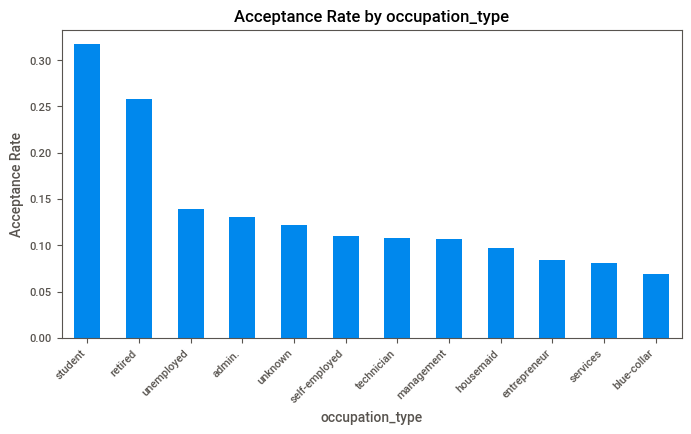

,acceptance_rate_by_relationship_status
relationship_status,
single,0.140144
unknown,0.132353
divorced,0.102885
married,0.101664


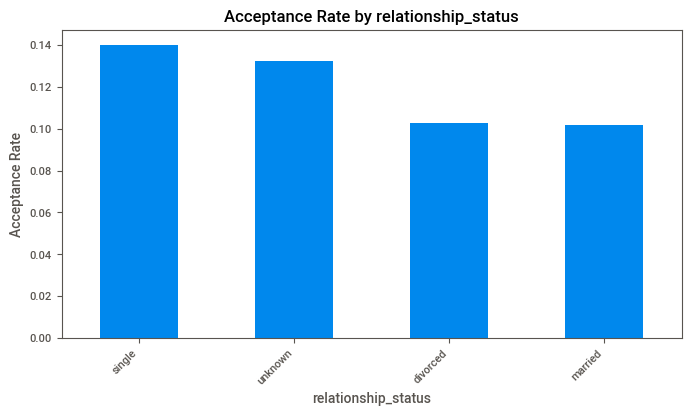

,acceptance_rate_by_education_background
education_background,
illiterate,0.187500
unknown,0.148649
university.degree,0.138559
professional.course,0.110026
high.school,0.106584
basic.4y,0.102587
basic.9y,0.082189
basic.6y,0.077008


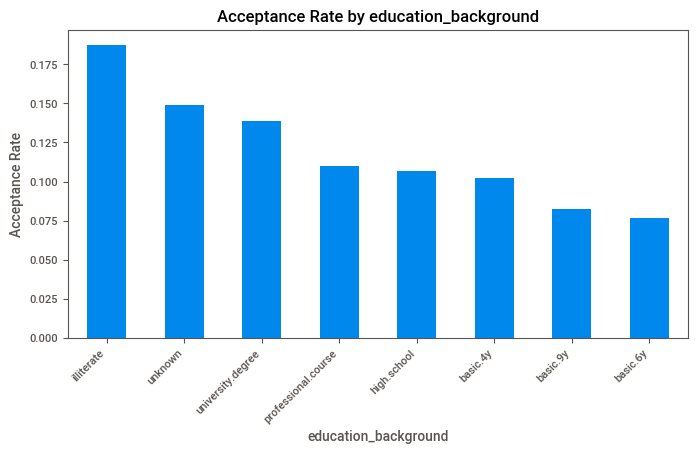

,acceptance_rate_by_prior_outcome_status
prior_outcome_status,
success,0.636607
failure,0.142392
nonexistent,0.088605


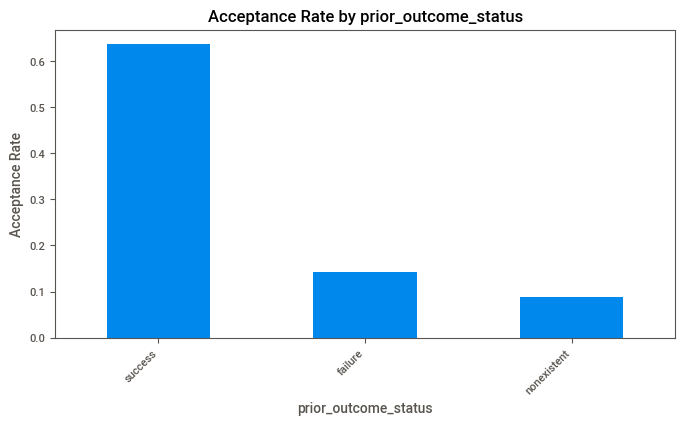

,acceptance_rate_by_last_contact_month
last_contact_month,
mar,0.513761
dec,0.475862
sep,0.457082
oct,0.431818
apr,0.209160
aug,0.103922
jun,0.103238
nov,0.101767
jul,0.091590


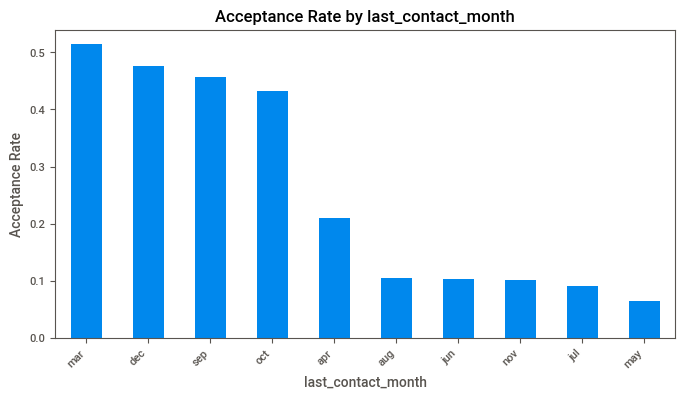

In [65]:
# comparing accceptance rate by specific categorical variables that looked interesting in sweetviz report
cat_cols_to_plot = [
    "occupation_type", 
    "relationship_status", 
    "education_background", 
    "prior_outcome_status",
    "last_contact_month"
]

for col in cat_cols_to_plot:
    rates = train.groupby(col)[target].mean().sort_values(ascending=False)
    display(rates.rename(f"acceptance_rate_by_{col}").to_frame())
    
    rates.plot(kind="bar", figsize=(8, 4))
    plt.title(f"Acceptance Rate by {col}")
    plt.ylabel("Acceptance Rate")
    plt.xlabel(col)
    plt.xticks(rotation=45, ha="right")
    plt.show()


In [66]:
# now numeric relationship with target
numeric_cols = train.select_dtypes(include=np.number).columns.drop(["id", target])

summary = train.groupby(target)[numeric_cols].mean().T
summary["difference_1_minus_0"] = summary[1] - summary[0]
display(summary.sort_values("difference_1_minus_0", ascending=False))

# forrelation with target for numeric features
corrs = train[numeric_cols.tolist() + [target]].corr(numeric_only=True)[target].drop(target)
display(corrs.abs().sort_values(ascending=False).head(10).rename("abs_corr_with_target").to_frame())

accepted_offer,0,1,difference_1_minus_0
contact_time_minutes,220.352078,548.551009,328.198931
customer_age,39.899470,40.940242,1.040772
consumer_confidence_index,-40.591596,-39.852571,0.739025
prior_contact_count,0.132820,0.493136,0.360316
is_repeat_customer,0.113015,0.321400,0.208385
recent_contact_flag,0.015837,0.208075,0.192238
consumer_price_index,93.602689,93.356666,-0.246023
contact_attempt_count,2.620592,2.053028,-0.567563
economic_activity_change,0.244368,-1.238923,-1.483291
reference_interest_rate,3.805827,2.110895,-1.694932


,abs_corr_with_target
contact_time_minutes,0.404403
employment_level_index,0.355823
days_since_prior_contact,0.320040
recent_contact_flag,0.319990
reference_interest_rate,0.308602
economic_activity_change,0.298351
prior_contact_count,0.229570
is_repeat_customer,0.191969
consumer_price_index,0.134264
contact_attempt_count,0.065250


### 2. Data Preparation

In [67]:
X = train.drop(columns=[target])
y = train[target]

test_ids = test["id"]

# drop id from features
X = X.drop(columns=["id"])
X_test = test.drop(columns=["id"])

categorical_cols = X.select_dtypes(include="object").columns.tolist()
numeric_cols = X.select_dtypes(include=np.number).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)
 

Categorical columns: ['occupation_type', 'relationship_status', 'education_background', 'has_credit_issue', 'mortgage_status', 'personal_loan_status', 'last_contact_month', 'day_of_week', 'prior_outcome_status']
Numeric columns: ['customer_age', 'contact_time_minutes', 'contact_attempt_count', 'days_since_prior_contact', 'prior_contact_count', 'economic_activity_change', 'consumer_price_index', 'consumer_confidence_index', 'reference_interest_rate', 'employment_level_index', 'is_repeat_customer', 'recent_contact_flag']


C:\Users\ivpri\AppData\Local\Temp\ipykernel_27868\3617353027.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include="object").columns.tolist()


### 3. Feature Engineering or Feature Selection

In [68]:
# contained in one function
def add_features(df):
    df = df.copy()
    
    df["contact_time_per_attempt"] = np.where(
        df["contact_attempt_count"] == 0,
        df["contact_time_minutes"],
        df["contact_time_minutes"] / df["contact_attempt_count"]
    )
    
    # flag for whether the customer had any prior contact
    df["had_prior_contact"] = (df["prior_contact_count"] > 0).astype(int)
    
    # flag longer calls using median
    median_contact_time = train["contact_time_minutes"].median()
    df["long_contact_flag"] = (df["contact_time_minutes"] > median_contact_time).astype(int)
    
    # create interaction var between repeat customer and recent contact
    df["repeat_recent_contact"] = df["is_repeat_customer"] * df["recent_contact_flag"]
    
    return df

In [69]:
X2 = add_features(X)
X_test2 = add_features(X_test)

In [70]:
# using stratified instead of regular kfold or train test split to maintain target balance in folds
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

X_base_encoded = pd.get_dummies(X, drop_first=True)
X2_encoded = pd.get_dummies(X2, drop_first=True)

# Align columns just in case
X2_encoded = X2_encoded.reindex(columns=X2_encoded.columns, fill_value=0)

lr_base = LogisticRegression(max_iter=3000)
lr_fe = LogisticRegression(max_iter=3000)

base_scores = cross_val_score(lr_base, X_base_encoded, y, cv=cv, scoring="roc_auc")
fe_scores = cross_val_score(lr_fe, X2_encoded, y, cv=cv, scoring="roc_auc")

feature_compare = pd.DataFrame({
    "Feature Set": ["Original features", "Original + engineered features"],
    "Mean CV ROC AUC": [base_scores.mean(), fe_scores.mean()],
    "CV Std": [base_scores.std(), fe_scores.std()]
})

display(feature_compare)

c:\Users\ivpri\gsb545\.venv_clean\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\ivpri\gsb545\.venv_clean\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessi

,Feature Set,Mean CV ROC AUC,CV Std
0,Original features,0.933931,0.004960
1,Original + engineered features,0.932717,0.004284


In [71]:
# Continue with engineered features
X_model = X2_encoded.copy()

# Encode final test set the same way and align columns
X_test_model = pd.get_dummies(X_test2, drop_first=True)
X_test_model = X_test_model.reindex(columns=X_model.columns, fill_value=0)

print("Train model shape:", X_model.shape)
print("Test model shape:", X_test_model.shape)

Train model shape: (32950, 58)
Test model shape: (8238, 58)


### 4. Modeling and Evaluation

In [72]:
# Model 1: logistic regression with hyperparameter tuning using RandomizedSearchCV
lr = LogisticRegression(max_iter=3000)

lr_params = {
    "C": [0.01, 0.1, 1, 10]
}

lr_search = RandomizedSearchCV(
    lr,
    param_distributions=lr_params,
    n_iter=4,
    scoring="roc_auc",
    cv=cv,
    random_state=42,
    n_jobs=-1
)

lr_search.fit(X_model, y)

print("best logreg params:", lr_search.best_params_)
print("CV ROC AUC:", lr_search.best_score_)

best logreg params: {'C': 0.01}
CV ROC AUC: 0.9332445277409288


c:\Users\ivpri\gsb545\.venv_clean\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [73]:
# Model 2: random forest
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

rf_params = {
    "n_estimators": [200, 400],
    "max_depth": [5, 10, None],
    "min_samples_leaf": [1, 5, 10],
    "max_features": ["sqrt", "log2"]
}

rf_search = RandomizedSearchCV(
    rf,
    param_distributions=rf_params,
    n_iter=10,
    scoring="roc_auc",
    cv=cv,
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_model, y)

print("best rf params:", rf_search.best_params_)
print("cv ROC AUC:", rf_search.best_score_)

best rf params: {'n_estimators': 200, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'max_depth': None}
cv ROC AUC: 0.9480982183406799


In [74]:
# model 3: gradient boosting
gb = GradientBoostingClassifier(random_state=42)

gb_params = {
    "n_estimators": [100, 200],
    "learning_rate": [0.03, 0.05, 0.1],
    "max_depth": [2, 3, 4]
}

gb_search = RandomizedSearchCV(
    gb,
    param_distributions=gb_params,
    n_iter=8,
    scoring="roc_auc",
    cv=cv,
    random_state=42,
    n_jobs=-1
)

gb_search.fit(X_model, y)

print("best gradient boosting params:", gb_search.best_params_)
print("cv ROC AUC:", gb_search.best_score_)

best gradient boosting params: {'n_estimators': 100, 'max_depth': 4, 'learning_rate': 0.1}
cv ROC AUC: 0.9474761418412682


In [75]:
# %%
# Evaluate tuned models using multiple metrics with cross-validation

models = {
    "Logistic Regression": lr_search.best_estimator_,
    "Random Forest": rf_search.best_estimator_,
    "Gradient Boosting": gb_search.best_estimator_
}

results = []

for name, model in models.items():
    auc_scores = cross_val_score(model, X_model, y, cv=cv, scoring="roc_auc")
    acc_scores = cross_val_score(model, X_model, y, cv=cv, scoring="accuracy")
    f1_scores = cross_val_score(model, X_model, y, cv=cv, scoring="f1")
    recall_scores = cross_val_score(model, X_model, y, cv=cv, scoring="recall")
    precision_scores = cross_val_score(model, X_model, y, cv=cv, scoring="precision")

    results.append({
        "Model": name,
        "CV ROC AUC": auc_scores.mean(),
        "CV Accuracy": acc_scores.mean(),
        "CV F1": f1_scores.mean(),
        "CV Recall": recall_scores.mean(),
        "CV Precision": precision_scores.mean()
    })

results_df = pd.DataFrame(results).sort_values("CV ROC AUC", ascending=False)
display(results_df)

c:\Users\ivpri\gsb545\.venv_clean\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\ivpri\gsb545\.venv_clean\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessi

,Model,CV ROC AUC,CV Accuracy,CV F1,CV Recall,CV Precision
1,Random Forest,0.948098,0.914143,0.561543,0.487752,0.662149
2,Gradient Boosting,0.947476,0.916540,0.594346,0.542396,0.658059
0,Logistic Regression,0.933278,0.909954,0.500512,0.400269,0.668915


In [76]:
# --> logreg feature evaluation using coefficients

best_lr = lr_search.best_estimator_
best_lr.fit(X_model, y)

coef_df = pd.DataFrame({
    "feature": X_model.columns,
    "coefficient": best_lr.coef_[0],
    "abs_coefficient": np.abs(best_lr.coef_[0])
}).sort_values("abs_coefficient", ascending=False)

display(coef_df.head(20))

c:\Users\ivpri\gsb545\.venv_clean\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,feature,coefficient,abs_coefficient
14,long_contact_flag,0.812555,0.812555
48,last_contact_month_may,-0.726213,0.726213
47,last_contact_month_mar,0.587795,0.587795
5,economic_activity_change,-0.380466,0.380466
6,consumer_price_index,0.346293,0.346293
16,occupation_type_blue-collar,-0.237163,0.237163
43,last_contact_month_aug,0.228616,0.228616
37,has_credit_issue_unknown,-0.226895,0.226895
20,occupation_type_retired,0.219886,0.219886
45,last_contact_month_jul,0.203177,0.203177


,feature,importance
1,contact_time_minutes,0.240017
12,contact_time_per_attempt,0.124911
9,employment_level_index,0.091778
8,reference_interest_rate,0.089360
14,long_contact_flag,0.048745
0,customer_age,0.041293
7,consumer_confidence_index,0.036979
5,economic_activity_change,0.035118
6,consumer_price_index,0.031972
15,repeat_recent_contact,0.029177


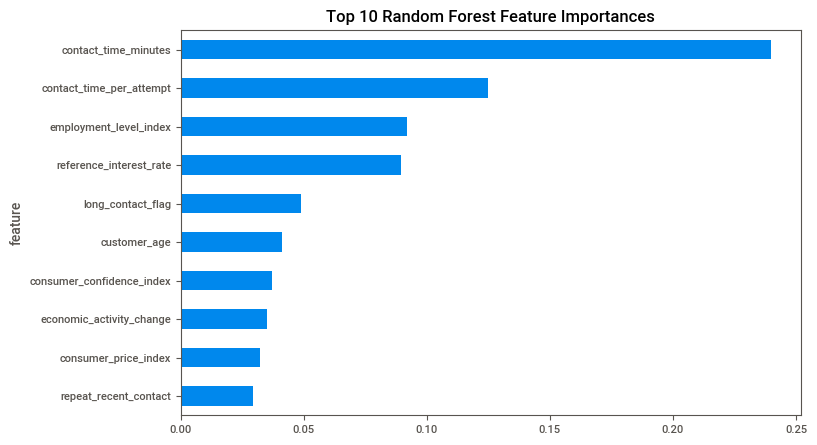

In [77]:
# random foresgt feature importance for comparison

best_rf = rf_search.best_estimator_
best_rf.fit(X_model, y)

rf_importance = pd.DataFrame({
    "feature": X_model.columns,
    "importance": best_rf.feature_importances_
}).sort_values("importance", ascending=False)

display(rf_importance.head(20))

rf_importance.head(10).sort_values("importance").plot(
    x="feature",
    y="importance",
    kind="barh",
    legend=False,
    figsize=(8, 5)
)
plt.title("Top 10 Random Forest Feature Importances")
plt.show()

### 5. Ensembling

In [78]:
# start testing ensembling --> probability averaging
def cv_soft_ensemble(models_dict, X, y, cv):
    aucs = []
    accs = []
    f1s = []
    recalls = []
    precisions = []

    for train_idx, val_idx in cv.split(X, y):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        prob_sum = np.zeros(len(y_val))

        for name, model in models_dict.items():
            model.fit(X_tr, y_tr)
            prob_sum += model.predict_proba(X_val)[:, 1]

        avg_probs = prob_sum / len(models_dict)
        preds = (avg_probs >= 0.5).astype(int)

        aucs.append(roc_auc_score(y_val, avg_probs))
        accs.append(accuracy_score(y_val, preds))
        f1s.append(f1_score(y_val, preds))
        recalls.append(recall_score(y_val, preds))
        precisions.append(precision_score(y_val, preds))

    return {
        "CV ROC AUC": np.mean(aucs),
        "CV Accuracy": np.mean(accs),
        "CV F1": np.mean(f1s),
        "CV Recall": np.mean(recalls),
        "CV Precision": np.mean(precisions)
    }

In [79]:
ensemble_all_scores = cv_soft_ensemble(models, X_model, y, cv)

ensemble_two_scores = cv_soft_ensemble(
    {
        "Random Forest": rf_search.best_estimator_,
        "Gradient Boosting": gb_search.best_estimator_
    },
    X_model,
    y,
    cv
)

ensemble_results = pd.DataFrame([
    {"Model": "Ensemble: LR + RF + GB", **ensemble_all_scores},
    {"Model": "Ensemble: RF + GB", **ensemble_two_scores}
])

display(pd.concat([results_df, ensemble_results], ignore_index=True).sort_values("CV ROC AUC", ascending=False))

c:\Users\ivpri\gsb545\.venv_clean\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\ivpri\gsb545\.venv_clean\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessi

,Model,CV ROC AUC,CV Accuracy,CV F1,CV Recall,CV Precision
4,Ensemble: RF + GB,0.949002,0.916085,0.585122,0.524630,0.662143
0,Random Forest,0.948098,0.914143,0.561543,0.487752,0.662149
3,Ensemble: LR + RF + GB,0.947662,0.915751,0.564825,0.484791,0.677068
1,Gradient Boosting,0.947476,0.916540,0.594346,0.542396,0.658059
2,Logistic Regression,0.933278,0.909954,0.500512,0.400269,0.668915


### 6. Results Summary

In [80]:
# final model is selected using primarily cv roc-auc, with F1/recall also considered because the positive class is the campaign response we care about.
final_results = pd.concat([results_df, ensemble_results], ignore_index=True)

final_results["Validation Method"] = "5-fold StratifiedKFold CV"
final_results["Main Metric"] = "ROC AUC"
final_results["Preprocessing / Features"] = "One-hot encoding + engineered contact features"

final_results = final_results[
    [
        "Model",
        "Preprocessing / Features",
        "Validation Method",
        "Main Metric",
        "CV ROC AUC",
        "CV Accuracy",
        "CV F1",
        "CV Recall",
        "CV Precision"
    ]
].sort_values("CV ROC AUC", ascending=False)

display(final_results)

final_model_name = final_results.iloc[0]["Model"]
print("Final model:", final_model_name)

,Model,Preprocessing / Features,Validation Method,Main Metric,CV ROC AUC,CV Accuracy,CV F1,CV Recall,CV Precision
4,Ensemble: RF + GB,One-hot encoding + engineered contact features,5-fold StratifiedKFold CV,ROC AUC,0.949002,0.916085,0.585122,0.524630,0.662143
0,Random Forest,One-hot encoding + engineered contact features,5-fold StratifiedKFold CV,ROC AUC,0.948098,0.914143,0.561543,0.487752,0.662149
3,Ensemble: LR + RF + GB,One-hot encoding + engineered contact features,5-fold StratifiedKFold CV,ROC AUC,0.947662,0.915751,0.564825,0.484791,0.677068
1,Gradient Boosting,One-hot encoding + engineered contact features,5-fold StratifiedKFold CV,ROC AUC,0.947476,0.916540,0.594346,0.542396,0.658059
2,Logistic Regression,One-hot encoding + engineered contact features,5-fold StratifiedKFold CV,ROC AUC,0.933278,0.909954,0.500512,0.400269,0.668915


Final model: Ensemble: RF + GB


### 7. Final Model and Predictions

In [81]:
rf_final = rf_search.best_estimator_
gb_final = gb_search.best_estimator_

rf_final.fit(X_model, y)
gb_final.fit(X_model, y)

final_probs = (
    rf_final.predict_proba(X_test_model)[:, 1] +
    gb_final.predict_proba(X_test_model)[:, 1]
) / 2


final_preds = (final_probs >= 0.5).astype(int)

submission = pd.DataFrame({
    "id": test_ids,
    "prediction": final_preds
})

display(submission.head())
display(submission["prediction"].value_counts(normalize=True).rename("prediction_rate").to_frame())

,id,prediction
0,32884,0
1,3169,0
2,32206,1
3,9403,0
4,14020,0


,prediction_rate
prediction,
0,0.912479
1,0.087521


In [82]:
submission.to_csv("inampudi_priya_predictions.csv", index=False)